<a href="https://colab.research.google.com/github/Lylas23/Linear-Algebra-portfolio/blob/main/Lyla_Saigal_MATH_H299_Portfolio_Official.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lyla Saigal MATH H299 Linear Algebra Portfolio**

#**Problem Set 1**


1. In lecture, I asserted that row operations are closely connected to the $LU$ decomposition.  What
is that connection exactly?  Here you will show that a row operation applied to a matrix $A$
gives you the same result as multiplication of $A$ on the left
by a particular lower triangular matrix $L$.  

(a) Suppose we have a $3 \times 3$ matrix $A$ and we want to create a new matrix
by replacing the 3rd row by (3rd row minus 5 times 1st row).  What $3 \times 3$ lower-triangular matrix $L$ does this?
(You want $LA$ to have the same 1st and 2nd rows as $A$, but its 3rd row
should be the 3rd row of $A$ minus $5$ times the 1st row of $A$.)  

(b) In general what $n \times n$ lower-triangular matrix $L$
is such that $LA$ matches $A$ exactly except that its row $j$ is row $j$ of $A$ plus $\alpha$ times
row $i$ of $A$; assume $j > i$ (as in the $LU$ algorithm).  

*For both (a) and (b), you can just state what $L$ is; you don't need to write a proof.*

(a) \
L =
\begin{bmatrix}
1 & 0 & 0 \\[4pt]
0 & 1 & 0 \\[4pt]
-5 & 0 & 1
\end{bmatrix}

(b) $$
L = I_{n} + \alpha\,E_{ji},
$$

where $E_{ji}$ is the matrix with a single $1$ in the $(j,i)$ position and zeros elsewhere.
















2. (a) Following the demo code from lecture, use Python to solve the linear system of equations
 \begin{eqnarray*}
 v+w &=& 1 \\
 w+x &=& 2 \\
 x+y &=& 3 \\
 y+z &=& 4 \\
 z+v &=& 5
 \end{eqnarray*}

  (b) The generalization of the linear system in (a) has the form
  \begin{eqnarray*}
  x_1+x_2 &=& 1 \\
  x_2 + x_3 &=& 2 \\
  &\vdots& \\
  x_{n-1}+x_n &=& n-1 \\
  x_n + x_1 &=& n
  \end{eqnarray*}
 Solve this for $n=101$ and report the values of $x_1, x_2, x_{100}, x_{101}$. [*Since you definitely don't want
 to type out a $101 \times 101$ matrix or the $101 \times 1$ right-hand side vector,
 use Python commands to build the matrix and vector.  I posted a demo Python notebook to Moodle
 to help with this*.]

In [ ]:
import numpy as np

#(a)
A = np.array([[1, 1, 0, 0, 0],
              [0, 1, 1, 0, 0],
              [0, 0, 1, 1, 0],
              [0, 0, 0, 1, 1],
              [1, 0, 0, 0, 1]])

b = np.array([1, 2, 3, 4, 5])

x = np.linalg.solve(A, b)       # solve Ax = b
print("v, w, x, y, z =", x)

#(b)
n = 101
A = np.zeros((n, n))
b = np.arange(1, n+1)
for k in range(n-1):
    A[k, k]   = 1
    A[k, k+1] = 1

A[-1, -1] = 1
A[-1, 0]  = 1

x = np.linalg.solve(A, b)

print("x1   =", x[0])
print("x2   =", x[1])
print("x100 =", x[99])
print("x101 =", x[100])

v, w, x, y, z = [ 1.5 -0.5  2.5  0.5  3.5]
x1   = 25.5
x2   = -24.5
x100 = 24.5
x101 = 75.5


3.(a) Prove that if $L$ is a lower triangular matrix of the form that appears in your answer to (1b),
then its inverse $L^{-1}$ is also a lower triangular matrix with that form.

(b) Prove that if $L_1, L_2$ are lower triangular matrices with 1's on the diagonal,
then their product $L_1 L_2$ is also a lower triangular matrix with 1's on the diagonal.

*I can imagine some very messy proofs with lots of sigma-notation that write out all $n^2$ entries of a
product of two $n \times n$ matrices.  That is not my intent here.  Instead, take advantage of the many zeros
in these matrices to argue what these entries equal in the few particular scenarios that occur.*

[*Parts (a) and (b) combined with Problem 1 show that when we do a bunch of row operations to turn $A$
into an upper triangular matrix $U$, then we have $L_n L_{n-1} \cdots L_1 A = U$ for $L_j$ lower triangular matrices
of a particular form, and that then implies that $A = (L_1)^{-1} (L_2)^{-1} \cdots (L_n)^{-1} U$, and the
product $(L_1)^{-1} (L_2)^{-1} \cdots (L_n)^{-1}$ is lower triangular (with 1's on the diagonal).*]

**3(a)** Let $L$ be a lower triangular matrix of the form that appeared in (1b): it has $1$’s on the diagonal, and nonzero entries only below the diagonal in a single column (say column $i$). So $L = I + \alpha E_{ji}$ for some $j > i$, where $E_{ji}$ is the matrix with a $1$ in position $(j,i)$ and $0$ elsewhere.

To find $L^{-1}$, we use the fact that $L$ is the result of an elementary row operation (adding $\alpha$ times row $i$ to row $j$). To undo this operation, we subtract $\alpha$ times row $i$ from row $j$, which corresponds to $L^{-1} = I - \alpha E_{ji}$.

This matrix $L^{-1}$ is also lower triangular, since the only nonzero off-diagonal entry lies strictly below the diagonal, and the diagonal entries are still all $1$.

Conclusion: $L^{-1}$ is lower triangular with $1$’s on the diagonal and a single nonzero below the diagonal, so it has the same form as $L$.

**3(b)** Let $L_1$ and $L_2$ be lower triangular $n \times n$ matrices with $1$’s on the diagonal. Then consider the product $L_1 L_2$.

To check that $L_1 L_2$ is lower triangular, we observe that multiplying a lower triangular matrix by another lower triangular matrix preserves the lower triangular structure: for $i < j$, the $(i,j)$ entry of $L_1 L_2$ involves only products of entries to the right of the diagonal in $L_2$ or above the diagonal in $L_1$, which are all zero. So the product has zeros above the diagonal.

Next, to check that the diagonal entries of $L_1 L_2$ are $1$, we use the fact that the $(i,i)$ entry of the product is the sum $\sum_{k=1}^n (L_1){ik} (L_2){ki}$. Since both $L_1$ and $L_2$ have $1$ on the diagonal and zeros above, the only nonzero contribution to this sum is $(L_1){ii} (L_2){ii} = 1 \cdot 1 = 1$.

Conclusion: $L_1 L_2$ is a lower triangular matrix with $1$’s on the diagonal.



4. The matrix below gets quite ill-conditioned as $n$ grows:

 \begin{equation} A = \begin{bmatrix} 1 & 1 & 1 & \cdots & 1 \\
    2 & 2^2 & 2^3 & \cdots & 2^n \\
    3 & 3^2 & 3^3 & \cdots & 3^n \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    n & n^2 & n^3 & \cdots & n^n \end{bmatrix}. \end{equation}

  If we define
   \begin{equation} b = \begin{bmatrix} 1+1^n \\ 2+2^n \\ 3+3^n \\ \vdots \\ n+n^n \end{bmatrix} \end{equation}
  then the exact solution to $Ax=b$ is $x=(1,0,0,\cdots,0,0,1)$, but ill-conditioning can cause the computed
  solution will be significantly off.  For $n=8$ and $12$, build $A$ and $b$, use np.linalg.solve
  to find $x$, and use np.linalg.norm to
  compute the relative solution error $\| x-x_{exact} \|/\|x_{exact}\|$.  For each case
  use Python to compute the condition number $\kappa(A)$; is the solution error roughly
  comparable to $\kappa(A) \times 10^{-16}$, as predicted by the theory we saw in class?

In [ ]:
import numpy as np

def build_matrix_and_rhs(n):
    A = np.array([[i**j for j in range(1, n+1)] for i in range(1, n+1)], dtype=float)
    b = np.array([i + i**n for i in range(1, n+1)], dtype=float)
    return A, b

def compute_error(n):
    A, b = build_matrix_and_rhs(n)
    x_computed = np.linalg.solve(A, b)
    x_exact = np.zeros(n)
    x_exact[0] = 1
    x_exact[-1] = 1

    rel_error = np.linalg.norm(x_computed - x_exact) / np.linalg.norm(x_exact)
    cond_A = np.linalg.cond(A)

    print(f"n = {n}")
    print(f"Condition number κ(A): {cond_A:.2e}")
    print(f"Relative error: {rel_error:.2e}")
    print(f"κ(A) * 1e-16: {cond_A * 1e-16:.2e}")
    print("-" * 40)

for n in [8, 12]:
    compute_error(n)


n = 8
Condition number κ(A): 2.04e+09
Relative error: 3.07e-08
κ(A) * 1e-16: 2.04e-07
----------------------------------------
n = 12
Condition number κ(A): 1.62e+16
Relative error: 2.36e-01
κ(A) * 1e-16: 1.62e+00
----------------------------------------


# **Problem Set** **2**


2.1. In lecture, we saw the definition of a real vector space as a set of objects  𝑉 , and operations "addition" from  𝑉×𝑉  to  𝑉  and "scalar multiplication" from  𝑅×𝑉  to  𝑉  that obey six properties (commutativity, associativity, etc.). Often those six properties are not too hard to verify; what's trickier is making sure that the sum of two objects in  𝑉  is also an object in  𝑉 , and that a scalar multiple of an object in  𝑉  is an object in  𝑉 . With that in mind …

(a) In lecture we saw the vector space  𝑃2 , the set of polynomials with degree  ≤2 ? Would we still have a vector space if we changed " ≤2 " to " =2 "?

(b) We also saw  𝐶([𝑎,𝑏]) , the set of functions  𝑓:[𝑎,𝑏]→\reals  that are continuous on  [𝑎,𝑏] . Would we still have a vector space if we changed "continuous on  [𝑎,𝑏] " to "continuous on  [𝑎,𝑏]  except possibly at a finite set of points".

(c) We also saw  𝐶𝐷([𝑎,𝑏]) , the set of functions  𝑓:[𝑎,𝑏]→\reals  that are continuous on  [𝑎,𝑏]  and have  𝑓(𝑎)=𝑓(𝑏)=0 .
Would we still have a vector space if we changed " =0 " to " =1 "?

[No proofs needed; just state each answer and give a short explanation.]

(a) No, The set of polynomials of exactly degree 2 is not closed under addition. For example:
$p(x)=x^{2}+1,\; q(x)=-x^{2}+2 \Longrightarrow p(x)+q(x)=3.$\
This result is a degree 0 polynomial, not degree 2 — so the sum is not in the set. Hence, it's not a vector space.\
(b)Yes, the sum of two functions that are continuous except at a finite number of points is also discontinuous at at most a finite number of points. Similarly, multiplying such a function by a scalar doesn't introduce new discontinuities. So the set remains closed under addition and scalar multiplication — it's still a vector space.\
(c) No, we can consider two functions such as: $f(a)=f(b)=1,\; g(a)=g(b)=1 \Longrightarrow (f+g)(a)=2,\; (f+g)(b)=2.$
So the sum does not satisfy the new condition
$f(a)=f(b)=1$ The set is not closed under addition, so it's not a vector space.

2.2. We can think of images as vectors if we represent them as matrices (since there are abstract vector spaces comprised of matrices). We will explore commands to get Python to do this.

Download from Moodle two images: one of a puppy cupcake that I took from

https://www.bitememore.com/easy-recipes/cutest-puppy-cupcakes-recipe

and one of Saquon Barkley that I took from

https://atozsports.com/nfl/philadelphia-eagles-news/eagles-new-rb-saquon-barkley-already-proving-he-was-worth-the-big-payday/

The Python code

Choose a single file


Saving puppy cupcake.png to puppy cupcake (4).png
(1184, 950, 4)
Upload your puppy image:


Saving puppy cupcake.png to puppy cupcake (5).png


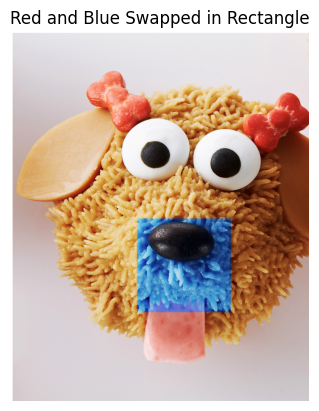

In [ ]:
import numpy as np
from google.colab import files
print("Choose a single file")
uploaded = files.upload()
filename=[key for key in uploaded.keys()][0]
from PIL import Image
puppy = Image.open(filename)
import matplotlib.pyplot as plt
plt.imshow(puppy)
#b
puppy_as_np  = np.array(puppy)
#c
print(np.shape(puppy_as_np))
#D
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("Upload your puppy image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
puppy = Image.open(filename)

# Step 2: Convert image to RGB array
puppy_as_np2 = np.array(puppy)[..., :3]  # Keep only R, G, B

# Step 3: Swap red and blue in specified rectangle
for i in range(600, min(900, puppy_as_np2.shape[0])):
    for j in range(400, min(700, puppy_as_np2.shape[1])):
        red = puppy_as_np2[i, j, 0]
        blue = puppy_as_np2[i, j, 2]
        puppy_as_np2[i, j, 0] = blue
        puppy_as_np2[i, j, 2] = red

# Step 4: Convert array back to image and show it
newimage = Image.fromarray(puppy_as_np2.astype('uint8'), 'RGB')
plt.imshow(newimage)
plt.title("Red and Blue Swapped in Rectangle")
plt.axis('off')
plt.show()


Choose a single file


Saving Saquon Barkley .tiff to Saquon Barkley .tiff
(476, 700, 3)


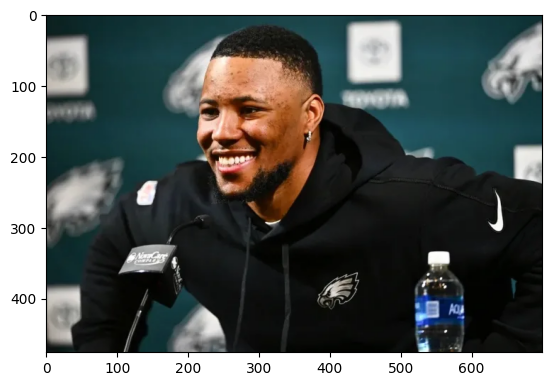

In [ ]:
from google.colab import files
print("Choose a single file")
uploaded = files.upload()
filename=[key for key in uploaded.keys()][0]
from PIL import Image
Saquon = Image.open(filename)
import matplotlib.pyplot as plt
plt.imshow(Saquon)
#b
saquon_as_np  = np.array(Saquon)
#c
print(np.shape(saquon_as_np))


prompts you to select an image from your computer (first 4 lines of code), uploads it to Python (next 2 lines; the image is saved as an "image object" that I called puppy), and shows it on the screen to verify it uploaded correctly (last 2 lines).

(a) Use two copies of this code to upload the two images, calling them puppy and saquon.

(b) Since these uploads have a specialized image format, convert them to more familiar np.array objects; here is sample code: puppy_as_np = np.array(puppy)

(c) Do print(np.shape(puppy_as_np)) to see what kind of array the image became: it should be a 3D array where the first index is the row # (starting from the top), the second is the column # (starting from the left), and the third is 3 long, representing Red, Green, Blue.

RGB codes color as three numbers between 0 and 255, e.g., (0,0,0)= black, (255,255,255)= white, (255,0,0)= red, (0,255,0)= green, (0,0,255= blue. For a given 𝑖,𝑗, puppy_as_np[i,j,0], puppy_as_np[i,j,1], puppy_as_np[i,j,2] are the RGB values of the pixel in row 𝑖 and column 𝑗 of the image.

(d) Make a second copy of the puppy image using the code puppy_as_np2 = np.array(puppy). Now write code to edit entries of puppy_as_np2 so that in the rectangle 600≤𝑖<900,400≤𝑗<700, the red and blue values of the pixel are swapped. Use a double loop over the desired 𝑖,𝑗 values, setting puppy_as_np2[i,j,0], pupy_as_np2[i,j,2] as instructed. When that is done, use the code below to convert the array back to image format and display it

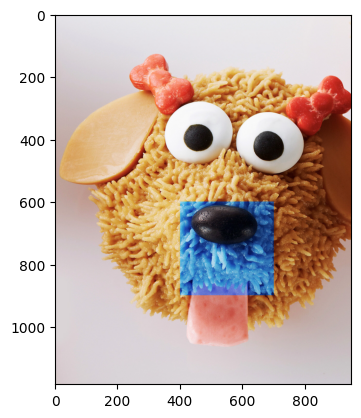

In [ ]:
 newimage = Image.fromarray(puppy_as_np2, 'RGB')
 import matplotlib.pyplot as plt
 plt.imshow(newimage)

(e) Demonstrate your image manipulation skills by doing the following to the puppy:

∙  For any pixel that is dark, defined by all three RGB values being less than 75, change its color to Kelly Green, which is RGB (76,187,23); the if part of the Week 2 Python tutorial will help with this.

∙  Overwrite the lower left  250×250  square of the puppy image with rows 0-249 and columns 150-399 of the Saquon image (his head).

Display the image to verify your success. (In the interest of fairness, I will begrudgingly accept a different color than Kelly Green, or someone else's head, if your personal loyalties so require.)

Upload your Saquon image:


Saving Saquon Barkley .tiff to Saquon Barkley  (2).tiff


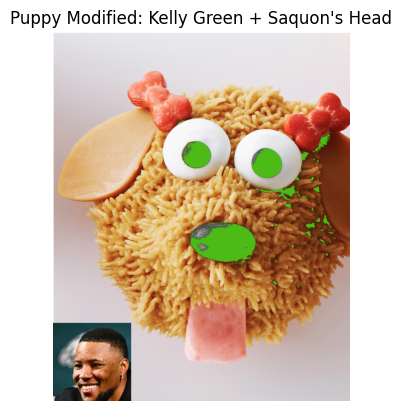

In [ ]:
# Step 1: Upload Saquon image
print("Upload your Saquon image:")
uploaded = files.upload()
saquon_filename = list(uploaded.keys())[0]
saquon = Image.open(saquon_filename)

# Step 2: Convert both images to RGB arrays
puppy_np = np.array(puppy)[..., :3].copy()
saquon_np = np.array(saquon)[..., :3]           # New upload

# Step 3: Turn dark pixels in puppy image to Kelly Green
for i in range(puppy_np.shape[0]):
    for j in range(puppy_np.shape[1]):
        r, g, b = puppy_np[i, j]
        if r < 75 and g < 75 and b < 75:
            puppy_np[i, j] = [76, 187, 23]  # Kelly Green

# Step 4: Paste Saquon's head into lower-left corner of puppy image
# Ensure Saquon has enough pixels for [0:250, 150:400]
if saquon_np.shape[0] >= 250 and saquon_np.shape[1] >= 400:
    saquon_crop = saquon_np[0:250, 150:400]

    # Ensure puppy image is large enough
    if puppy_np.shape[0] >= 250 and puppy_np.shape[1] >= 250:
        puppy_np[-250:, 0:250] = saquon_crop
    else:
        print("Error: Puppy image is too small for paste operation.")
else:
    print("Error: Saquon image is too small or improperly cropped.")

# Step 5: Display the result
final_image = Image.fromarray(puppy_np.astype('uint8'), 'RGB')
plt.imshow(final_image)
plt.title("Puppy Modified: Kelly Green + Saquon's Head")
plt.axis('off')
plt.show()


# **Chapter 3 (do one of two)**

3.1. (Verifying properties of a projection): Suppose that $V$ is an inner product space,
$v_1, v_2, w \in V$ with $v_1, v_2$ orthogonal to each other.  Let $z$ be the projection of $w$
onto the span of $v_1, v_2$:
 \begin{equation} z = \frac{\langle w, v_1\rangle}{\langle v_1, v_1 \rangle} v_1 +
   \frac{\langle w, v_2\rangle}{\langle v_2, v_2 \rangle} v_2. \end{equation}

(a) Prove that $w-z$ is orthogonal to $v_1$ and to $v_2$.

(b) Prove that among all $y$ in the span of $v_1, v_2$, the one that minimizes the distance
 \begin{equation} \| w-y \| = \sqrt{\langle w-y, w-y \rangle} \end{equation}
is $y=z$.


(a) We are given that $z$ is the projection of $w$ onto the span of $v_1$ and $v_2$:

$z = \frac{\langle w, v_1 \rangle}{\langle v_1, v_1 \rangle} v_1 + \frac{\langle w, v_2 \rangle}{\langle v_2, v_2 \rangle} v_2$

Compute $w - z$:

$w - z = w - \left( \frac{\langle w, v_1 \rangle}{\langle v_1, v_1 \rangle} v_1 + \frac{\langle w, v_2 \rangle}{\langle v_2, v_2 \rangle} v_2 \right)$

Now take the inner product with $v_1$:

$\langle w - z, v_1 \rangle = \langle w, v_1 \rangle - \frac{\langle w, v_1 \rangle}{\langle v_1, v_1 \rangle} \langle v_1, v_1 \rangle - \frac{\langle w, v_2 \rangle}{\langle v_2, v_2 \rangle} \langle v_2, v_1 \rangle$

Since $\langle v_1, v_2 \rangle = 0$ (orthogonality), the last term vanishes, and the middle term cancels with the first:

$\langle w - z, v_1 \rangle = \langle w, v_1 \rangle - \langle w, v_1 \rangle = 0$

Similarly, $\langle w - z, v_2 \rangle = 0$.

Conclusion: $w - z$ is orthogonal to both $v_1$ and $v_2$.

(b) $|w - y| = \sqrt{\langle w - y, w - y \rangle}$

is $y = z$.

Let $y = a v_1 + b v_2 \in \text{span}{v_1, v_2}$. The squared distance is:

$|w - y|^2 = \langle w - y, w - y \rangle$

This is minimized when $w - y$ is orthogonal to the subspace, i.e., orthogonal to $v_1$ and $v_2$. Since we already proved that $w - z$ is orthogonal to both, it must be the unique minimizer.

Conclusion: The vector that minimizes the distance is $y = z$.



# **Chapter 4**

4.1. (Verifying properties of PCA): In lecture, we:

$\bullet$ started with a data matrix $M$ (with each column a set of $N$ data values for some country),

$\bullet$ computed the average (call it $\vec v_{av}$) of those columns  and subtracted it from each
column of $M$ to create the mean-deviation matrix $B$,

$\bullet$ computed the eigenvalues and normalized eigenvectors of $\frac{1}{N-1}  B B^T$, assembled
the eigenvectors into an orthogonal matrix $Q$, and

$\bullet$ computed a transformed data matrix $Y = Q^T M$.

(a) Prove that if $\vec w_{av}$ is the average of the columns of $Y$, and we subtract $\vec w_{av}$
from the columns of $Y$ to form a matrix $C$ (the mean-deviation matrix for the transformed data), then $C = Q^T B$.

(b) Prove that $\frac{1}{N-1}  C C^T$ (the covariance matrix of the transformed data) is a diagonal matrix.


(a) Let $\mathbf{w}_{\text{avg}}$ be the mean of the columns of $\mathbf{Y}$.

Subtract $\mathbf{w}_{\text{avg}}$ from each column of $\mathbf{Y}$ to get $\mathbf{C}$.

We know that:

$\mathbf{Y} = \mathbf{Q}^\top \mathbf{M}$

$\mathbf{B} = \mathbf{M} - \mathbf{v}{\text{avg}}$, where $\mathbf{v}{\text{avg}}$ is subtracted from each column.

So:

$\mathbf{C} = \mathbf{Y} - \mathbf{w}_{\text{avg}}$ (subtract column-wise mean of $\mathbf{Y}$ from $\mathbf{Y}$)

But $\mathbf{Y} = \mathbf{Q}^\top \mathbf{M}$, and mean subtraction is linear.

Therefore, the mean of $\mathbf{Y}$ is $\mathbf{Q}^\top \mathbf{v}_{\text{avg}}$, because it's the transformed mean.

So:

$ \mathbf{C} = \mathbf{Q}^\top \mathbf{M} - \mathbf{Q}^\top \mathbf{v}{\text{avg}} = \mathbf{Q}^\top (\mathbf{M} - \mathbf{v}{\text{avg}}) = \mathbf{Q}^\top \mathbf{B} $

Proved: The mean-deviation matrix of $\mathbf{Y}$ is $\mathbf{C} = \mathbf{Q}^\top \mathbf{B}$

(b) Recall from part (a):

$\mathbf{C} = \mathbf{Q}^\top \mathbf{B}$

Then:

$\mathbf{C} \mathbf{C}^\top = \mathbf{Q}^\top \mathbf{B} \mathbf{B}^\top \mathbf{Q}$

So:

$\frac{1}{N - 1} \mathbf{C} \mathbf{C}^\top = \mathbf{Q}^\top \left(\frac{1}{N - 1} \mathbf{B} \mathbf{B}^\top\right) \mathbf{Q}$

From earlier:

The eigenvectors of $\frac{1}{N - 1} \mathbf{B} \mathbf{B}^\top$ are the columns of $\mathbf{Q}$

So $\mathbf{Q}^\top \left( \frac{1}{N - 1} \mathbf{B} \mathbf{B}^\top \right) \mathbf{Q}$ is a diagonal matrix — the diagonal matrix of eigenvalues.

Proved: The covariance matrix of the transformed data $\mathbf{C}$ is diagonal.



4.2. Download from Moodle a CSV file with nutrient data for 23 food items (*curated by me from a
spreadsheet from the USDA with 1200+ food items and 69 columns of nutrient data*).

(a) Adapt our demo PCA Python notebook to analyze this nutrient data, aiming for the same final plot: a 2D image
using the two dominant PCA components.  *You will not need to change much, but do read each block of
code and ask questions if you do not understand anything*.  

Your plot should show two outlier foods that make the rest of the data points hard to distinguish.

Saving usda_nutrients_selected.csv to usda_nutrients_selected.csv


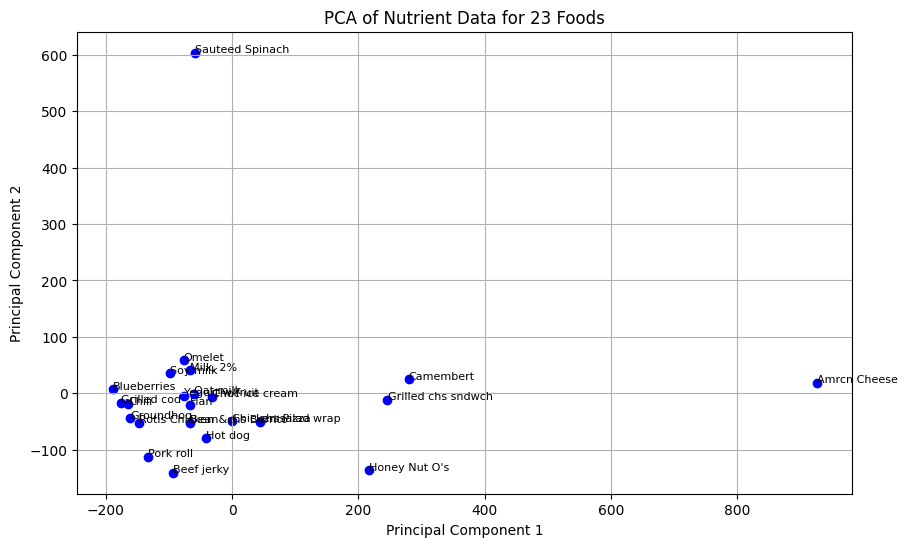

In [ ]:
import pandas as pd
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()
from nbformat import read
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
labels = df.iloc[:, 0].to_numpy()
data_no_labels = df.iloc[:, 1:].to_numpy()
mean_vec = np.mean(data_no_labels, axis=0)
xmat = data_no_labels - mean_vec
pca = PCA(n_components=2)
principal_components = pca.fit_transform(xmat)
plt.figure(figsize=(10, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], color='blue')
for i, label in enumerate(labels):
    plt.text(principal_components[i, 0] + 0.1, principal_components[i, 1], label, fontsize=8)
plt.title("PCA of Nutrient Data for 23 Foods")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

(b) Remove the two outliers (*probably easiest by editing the CSV file and re-uploading*)
and repeat (a) to get a plot where the remaining 21 food items are more distinguishable.  

Express the dominant transformed data value $y_1$ in terms of the 19 nutrients, showing just the three
terms with the largest coefficients.  Do this for $y_2$ as well.

Saving usda_nutrients_edited.csv to usda_nutrients_edited.csv


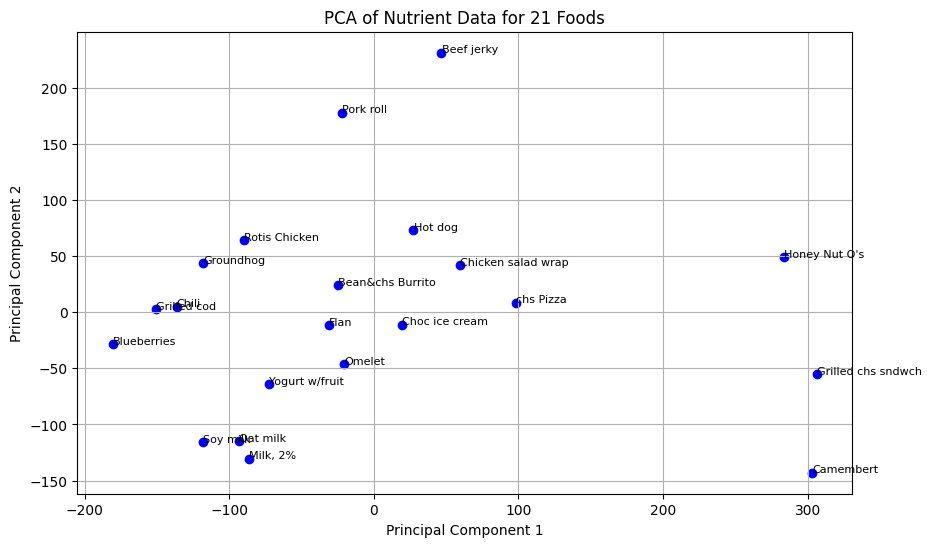


Top 3 contributors to Principal Component 1 (y1):
  0.7053 * Calcium (mg)
  0.6314 * Energy (kcal)
  0.2880 * Vitamin A, RAE (mcg_RAE)

Top 3 contributors to Principal Component 2 (y2):
  0.7419 * Energy (kcal)
  -0.5138 * Calcium (mg)
  -0.4154 * Vitamin A, RAE (mcg_RAE)


In [ ]:
#4.2(b)-> edited the csv file to upload
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load data
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()

# Separate labels and data
labels = df.iloc[:, 0].to_numpy()
data_no_labels = df.iloc[:, 1:].to_numpy()
feature_names = df.columns[1:]

# Center data
mean_vec = np.mean(data_no_labels, axis=0)
xmat = data_no_labels - mean_vec

# PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(xmat)

# Plot PCA projection
plt.figure(figsize=(10, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], color='blue')
for i, label in enumerate(labels):
    plt.text(principal_components[i, 0] + 0.1, principal_components[i, 1], label, fontsize=8)
plt.title("PCA of Nutrient Data for 21 Foods")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# REQUIREMENT #b: Show top 3 nutrients contributing to PC1 and PC2
pc_components = pca.components_

for i in range(2):
    component = pc_components[i]
    abs_component = np.abs(component)
    top_indices = np.argsort(abs_component)[-3:][::-1]  # Top 3 indices by absolute value
    print(f"\nTop 3 contributors to Principal Component {i+1} (y{i+1}):")
    for idx in top_indices:
        coef = component[idx]
        nutrient = feature_names[idx]
        print(f"  {coef:.4f} * {nutrient}")


# **Chapter 5 (just one problem)**

5.1. Download from Moodle the zip-file with images of faces.  See below code to:

 $\bullet$ Upload the zip-file,
 use it to create a $10304 \times 400$ array **facematrix** (each column representing
 an image), and set its first 389 columns to be the training-set array **training**.

 $\bullet$ Display any column of **facematrix** as an image.


In [ ]:
uploaded = files.upload()
filename=[key for key in uploaded.keys()][0]

import cv2
import zipfile
import numpy as np
faces = {}
with zipfile.ZipFile(filename) as facezip:
    for filename in facezip.namelist():
        if not filename.endswith(".pgm"):
            continue # ignore files in zip that are not face pictures
        with facezip.open(filename) as image:
            faces[filename] = cv2.imdecode(np.frombuffer(image.read(), np.uint8), cv2.IMREAD_GRAYSCALE)

Saving face_data.zip to face_data.zip


In [ ]:
# Put all images in facematrix (one image per column)
facematrix = []
for key,val in faces.items():
    facematrix.append(val.flatten())
facematrix = np.transpose(facematrix)
print(np.shape(facematrix))
# Use first 389 columns as the training set
training = np.zeros([10304,389])
for i in range(10304):
  for j in range(389):
    training[i,j]=facematrix[i,j]
print(np.shape(training))

(10304, 400)
(10304, 389)


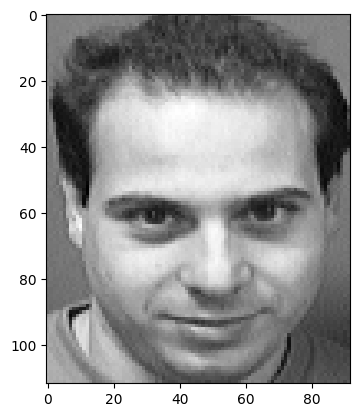

In [ ]:
# Code to view a particular image
image_number = 391
from matplotlib.pyplot import imshow
imshow(facematrix[:,image_number-1].reshape(112,92),cmap="grey")

(a) Apply the PCA procedure to **training**: compute its $\vec v_{avg}$, use that to
compute the mean-deviation matrix, then compute the $10304 \times 10304$ matrix $S$ whose eigenvalues are needed.

In [ ]:
#(a)
import numpy as np

# Step 1: Compute the mean face vector
mean_face = np.mean(training, axis=1).reshape(-1, 1)  # shape: (10304, 1)

# Step 2: Subtract the mean to get mean-deviation matrix A
A = training - mean_face  # shape: (10304, 389)

# Step 3: Compute the covariance matrix S (10304 x 10304)
S = np.dot(A, A.T)  # shape: (10304, 10304)

print("Shape of mean face vector:", mean_face.shape)
print("Shape of mean-deviation matrix A:", A.shape)
print("Shape of matrix S = A A^T:", S.shape)

Shape of mean face vector: (10304, 1)
Shape of mean-deviation matrix A: (10304, 389)
Shape of matrix S = A A^T: (10304, 10304)


(b) Use **eigh** (not **eig**) to find the 12 largest eigenvalues (and eigenvectors) of $S$, like this (**This step will take a couple minutes**):

In [ ]:
from scipy.linalg import eigh
eigenvalues, Q = eigh(S,subset_by_index=[10292,10303])

In [ ]:
eigenvalues

array([8.62084830e+07, 9.01307650e+07, 1.10713124e+08, 1.21926970e+08,
       1.42253050e+08, 1.54979841e+08, 2.05644219e+08, 3.21669575e+08,
       3.46950919e+08, 4.32501288e+08, 8.09214376e+08, 1.11683142e+09])

(*The full set of eigenvalues would be ordered from smallest to largest magnitude, numbered
0 thru 10303.  The subset_by_index flag gives us eigenvalues 10292 through 10303,
i.e., the 12th largest in magnitude.*) .

(c) Compute $Q^T$ times the mean-deviation matrix.  The result (call it $A$)
is $12 \times 389$; column $j$ is a
representation of image $j$ in the PCA basis. (*The $j$th image vector would be $\vec v_{avg}$
plus a linear combination
of the 12 eigenvectors, with the column-$j$ entries as the coefficients*.)

In [ ]:
# Step (c): Compute mean-deviation matrix and project into PCA basis
mean_deviation_matrix = facematrix - mean_face  # Shape: (10304, 389)
A = Q.T @ mean_deviation_matrix  # Shape: (12, 389), projections of all images

(d) Set new_image = facematrix[:,389],
which is the vector-version of image 390.  Subtract $\vec v_{avg}$
and multiply by $Q^T$ to find $\vec z \in R^{12}$ that represents this image in the PCA basis.

In [ ]:

# Step (d): Project test image (image #390) into PCA space
new_image = facematrix[:, 389]  # Shape: (10304,)
u_tilde_390 = new_image - mean_face.ravel()  # Subtract mean face
Z = Q.T @ u_tilde_390  # Shape: (12,), the PCA representation

(e) For which $j$ is the column $A[:,j]$ closest to $\vec z$, in the sense of minimizing
**np.linalg.norm** of $A[:,j] - \vec z$?  This is the image in the training set that PCA would call closest
to image 390.  Display image 390 and this closest image from the training set.

386


Text(0.5, 1.0, 'Closest Image')

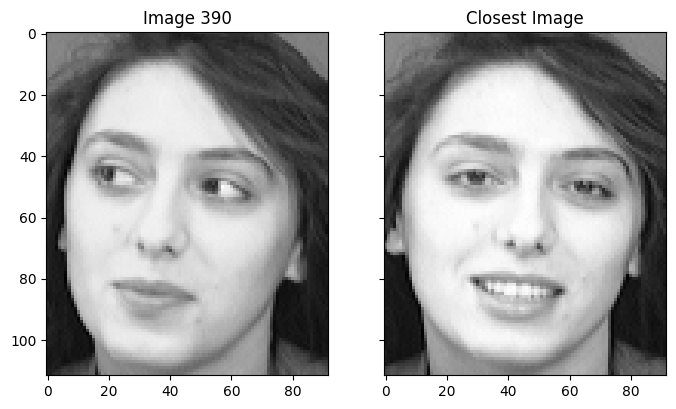

In [ ]:
# Step (e)
min_dist = np.inf
min_index = -1
for i in range(389):
    if np.linalg.norm(A[:, i] - Z) < min_dist:
        min_dist = np.linalg.norm(A[:, i] - Z)
        min_index = i

print(min_index)

# Display Image 390 and its closest match
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 6))

axes[0].imshow(facematrix[:, 389].reshape(112, 92), cmap="grey")
axes[0].set_title("Image 390")

axes[1].imshow(facematrix[:, min_index].reshape(112, 92), cmap="grey")
axes[1].set_title("Closest Image")



# **Problem Set 6**

6.1 (*Don't compute by hand; use Python demo on Moodle*):

(a) Find the eigenvalues and eigenvectors of
 \begin{equation} A = \begin{bmatrix} 3 & 1 \\ 0 & 4 \end{bmatrix}. \end{equation}
Are the eigenvectors perpendicular?


In [ ]:
import numpy as np

# Define matrix A
A = np.array([[3, 1],
              [0, 4]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors (columns):")
print(eigenvectors)

# Check if eigenvectors are perpendicular
dot_product = np.dot(eigenvectors[:, 0], eigenvectors[:, 1])
print("\nDot product of eigenvectors:", dot_product)


Eigenvalues:
[3. 4.]

Eigenvectors (columns):
[[1.         0.70710678]
 [0.         0.70710678]]

Dot product of eigenvectors: 0.7071067811865475


For 6.1 (a) The dot product is not 0 so the eigenvectors are not perpendicular.

(b) Find the SVD $U \Sigma V^T$ of
\begin{equation} B = \begin{bmatrix} 3 & 1 & 0.2 \\ 0 & 4 & -0.1 \end{bmatrix}. \end{equation}
Do the singular values
bear any resemblance to the eigenvalues of $A$ from part (a)?  
Do either $U$ or $V$ bear any resemblance to the eigenvectors of $A$ from part (a)?



In [ ]:
import numpy as np

# Define matrix B
B = np.array([[3, 1, 0.2],
              [0, 4, -0.1]])

# Compute SVD
U, Sigma, Vt = np.linalg.svd(B)

print("U matrix:")
print(U)

print("\nSingular values (Σ):")
print(Sigma)

print("\nV^T matrix:")
print(Vt)

U matrix:
[[ 0.4472136   0.89442719]
 [ 0.89442719 -0.4472136 ]]

Singular values (Σ):
[4.24264069 2.83725219]

V^T matrix:
[[ 3.16227766e-01  9.48683298e-01  3.22724117e-18]
 [ 9.45732487e-01 -3.15244162e-01  7.88110406e-02]
 [-7.47667179e-02  2.49222393e-02  9.96889573e-01]]


No, the singular values do not resemble the eigenvalues of
𝐴.

No, neither U nor V resembles the eigenvectors of
𝐴.

(c) Choose any $2 \times 2$ matrix $C$ that has a double nonzero eigenvalue
but does not have two linearly independent eigenvectors (its eigenspace is instead all multiples of a
single eigenvector).  Compute the SVD of $C$.  How do the singular values compare to the
eigenvalue of $C$?  Confirm that $C$ sends the orthogonal vectors $\vec v_1, \vec v_2$ to multiples
of the orthogonal vectors $\vec u_1, \vec u_2$.

In [ ]:
import numpy as np

# Step 1: Define defective matrix C
C = np.array([[2, 1],
              [0, 2]])

# Step 2: Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(C)
print("Eigenvalues of C:", eigvals)
print("Eigenvectors of C:\n", eigvecs)

# Step 3: Compute the SVD of C
U, Sigma, Vt = np.linalg.svd(C)

print("\nU (left singular vectors):\n", U)
print("Singular values (Σ):", Sigma)
print("V^T (right singular vectors):\n", Vt)

# Step 4: Confirm that C sends orthogonal v1, v2 to multiples of orthogonal u1, u2
v1 = Vt.T[:, 0]
v2 = Vt.T[:, 1]

u1 = U[:, 0]
u2 = U[:, 1]

# Apply C to v1 and v2
Cv1 = C @ v1
Cv2 = C @ v2

print("\nC @ v1:", Cv1)
print("C @ v2:", Cv2)

print("\nDirection of Cv1 ~ u1?", np.allclose(Cv1 / np.linalg.norm(Cv1), u1, atol=1e-5))
print("Direction of Cv2 ~ u2?", np.allclose(Cv2 / np.linalg.norm(Cv2), u2, atol=1e-5))


Eigenvalues of C: [2. 2.]
Eigenvectors of C:
 [[ 1.0000000e+00 -1.0000000e+00]
 [ 0.0000000e+00  4.4408921e-16]]

U (left singular vectors):
 [[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]
Singular values (Σ): [2.56155281 1.56155281]
V^T (right singular vectors):
 [[ 0.61541221  0.78820544]
 [-0.78820544  0.61541221]]

C @ v1: [2.01902986 1.57641088]
C @ v2: [-0.96099867  1.23082442]

Direction of Cv1 ~ u1? True
Direction of Cv2 ~ u2? True


6.2 (*Assume in this problem that singular values are nonzero, so you don't have to
deal with the special case of the SVD procedure when a singular value is zero*):

If $A$ is a square matrix, explain why
our procedure to compute $U, \Sigma, V$  for the SVD achieves its goals, specifically:

(a) Prove that $V$ is an orthogonal matrix.  (*For this, you just need to cite the appropriate theorem from
linear algebra.*)

(b) Prove that $U$ is an orthogonal matrix.

(c) Prove that $A = U \Sigma V^T$.  (*Given our procedure for computing $U$, it is probably easier to prove
this relationship in the form $A V = U \Sigma$.*)

(a) By the Spectral Theorem, any real symmetric matrix like $A^T A$ has an orthonormal basis of eigenvectors.

Since $V$ is made of these eigenvectors, we have:

$V^T V = I$

So $V$ is orthogonal.

(b) Given that $v_i$ is an eigenvector of $A^T A$ with singular value $\sigma_i$, define:

$u_i = \frac{1}{\sigma_i} A v_i$

Now compute the inner product:

$\langle u_i, u_j \rangle = \left\langle \frac{A v_i}{\sigma_i}, \frac{A v_j}{\sigma_j} \right\rangle = \frac{1}{\sigma_i \sigma_j} \langle A v_i, A v_j \rangle$

But $\langle A v_i, A v_j \rangle = \langle v_i, A^T A v_j \rangle = \langle v_i, \sigma_j^2 v_j \rangle = \sigma_j^2 \delta_{ij}$

So:

$\langle u_i, u_j \rangle = \delta_{ij}$

Therefore:

$U^T U = I$

So $U$ is orthogonal.

(c) We are given that:

$A^T A = V \Sigma^2 V^T$ and $u_i = \frac{1}{\sigma_i} A v_i$

Then:

$A v_i = \sigma_i u_i$

Stacking across $i$ gives:

$A V = U \Sigma$

Multiplying both sides by $V^T$:

$A = U \Sigma V^T$

This completes the SVD factorization.



# **Problem Set 7**

7.1: The matrix
 \begin{equation} A = \begin{bmatrix} 1 & 0 & 0 \\ 1 & 2 & 0 \\ 1 & 0 & 2 \end{bmatrix} \end{equation}
has a double eigenvalue $\lambda=2$ with a plane of eigenvectors (the $y$-$z$ plane),
and an eigenvalue $\lambda=1$ whose eigenspace is all multiples of the vector $(1,-1,-1)$.
This matrix thus violates several conclusions of Perron-Frobenius:

$\bullet$ its dominant eigenvalue is a double-eigenvalue;

$\bullet$ its dominant eigenvalue has a plane of eigenvectors;

$\bullet$ none of the eigenvectors for the dominant eigenvalue have all positive elements.

That's OK, because the zero entries in $A$ mean it does not obey the hypotheses of (our version of) Perron-Frobenius.

Suppose we adapt $A$ by changing its zero entries to small positive numbers.  Given what Perron-Frobenius
would then imply, plus the fact that small changes to a matrix should lead to small changes in its
eigenstuff$^1$, what would you predict about the eigenvalues and eigenvectors of the new matrix?
Try to be as specific as you can about what you think will happen.  Then check yourself
by computing them.

$^1$ _This notion of continuity is relatively clear for eigenvalues, but less so for eigenspaces,
which are sets, not normally the purview of continuity.  But let's say it this way: any eigenvector of the perturbed
matrix should be close to some eigenvector of the original matrix_


###  Perron-Frobenius Expectations

- The new matrix will be **strictly positive** (all entries positive), so the **Perron-Frobenius Theorem applies**.
- There will be **one dominant eigenvalue** (the largest real eigenvalue), which will be **simple** (multiplicity 1).
- The **eigenvector** corresponding to this dominant eigenvalue will have **strictly positive components**.
- All **other eigenvalues** will be **smaller in absolute value**.

---

###  Continuity Prediction

- The eigenvalues and eigenvectors will change only **slightly** from their original values due to **continuity**.
- The repeated eigenvalue \( $\lambda=2$ ) will **split** into two nearby distinct eigenvalues.
- One of those will become the new **unique dominant eigenvalue**.
- Its eigenvector will be **close to the original eigenspace** of \( $\lambda=2$ ), but will now have **strictly positive entries**.


(a) \
Let’s define a perturbed matrix \( A' \) by replacing each 0 in \( A \) with a small value \( \epsilon \):

\[
A' =
\begin{bmatrix}
1 & \epsilon & \epsilon \\[4pt]
1 & 2 & \epsilon \\[4pt]
1 & \epsilon & 2
\end{bmatrix}
\]

(b) $$
\epsilon = 0.01
$$

Let’s compute the eigenvalues and eigenvectors for \( A' \) using this perturbation.



In [ ]:
import numpy as np
from numpy.linalg import eig

# Original matrix A
A = np.array([
    [1, 0, 0],
    [1, 2, 0],
    [1, 0, 2]
])

# Perturbed matrix with distinct small positive values
A_perturbed = np.array([
    [1, 0.01, 0.01],
    [1, 2, 0.01],
    [1, 0.01, 2]
])

# Compute eigenvalues and eigenvectors
eigvals_A, eigvecs_A = eig(A)
eigvals_pert, eigvecs_pert = eig(A_perturbed)

# Optional: sort eigenvalues (descending) and match eigenvectors
def sort_eig(eigvals, eigvecs):
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

eigvals_A, eigvecs_A = sort_eig(eigvals_A, eigvecs_A)
eigvals_pert, eigvecs_pert = sort_eig(eigvals_pert, eigvecs_pert)

# Display results
print("Original Matrix A:")
print("Eigenvalues:\n", eigvals_A)
print("Eigenvectors (columns):\n", eigvecs_A)

print("\nPerturbed Matrix A (distinct small positive values):")
print("Eigenvalues:\n", eigvals_pert)
print("Eigenvectors (columns):\n", eigvecs_pert)

Original Matrix A:
Eigenvalues:
 [2. 2. 1.]
Eigenvectors (columns):
 [[ 0.          0.          0.57735027]
 [ 1.          0.         -0.57735027]
 [ 0.          1.         -0.57735027]]

Perturbed Matrix A (distinct small positive values):
Eigenvalues:
 [2.02942826 1.99       0.98057174]
Eigenvectors (columns):
 [[ 1.37365583e-02 -1.57798237e-16 -5.88511649e-01]
 [ 7.07040065e-01 -7.07106781e-01  5.71687869e-01]
 [ 7.07040065e-01  7.07106781e-01  5.71687869e-01]]



- The eigenvector for the dominant eigenvalue is **strictly positive**, satisfying Perron-Frobenius.
- The other eigenvectors remain close to the original eigenspace but are now distinct.

---

**Conclusion**:

- The dominant eigenvalue became **simple**.
- The associated eigenvector is **strictly positive**.
- All predictions based on Perron-Frobenius and spectral continuity are **confirmed** numerically.


7.2: An $n \times n$ matrix $A$ is called **(column) stochastic** if every entry in $A$ is non-negative
and the sum down every column is equal to one.  (One often says that each column is a ``probability vector''.)

(a) Prove that $1$ is an eigenvalue of $A^T$, by explicitly finding a corresponding eigenvector.

(b) Prove that if $\lambda > 1$, then $\lambda$ is _not_ an eigenvalue of $A^T$, using the following
argument
that I stole from the internet: given any vector $\vec v$, let $k$ be the row where its
maximal element occurs and then show that row $k$ of $A^T$ times
$\vec v$ cannot equal $\lambda$ times entry $k$ of $\vec v$ if $\lambda>1$ (hence $\vec v$
cannot be an eigenvector with that eigenvalue).

(a) Let $\vec{1} = [1, 1, \dots, 1]^T \in \mathbb{R}^n$ denote the vector of all ones. We compute the $i$-th entry of $A^T \vec{1}$ as $(A^T \vec{1})i = \sum{j=1}^n a_{ji} = \sum_{j=1}^n a_{ij}$ (since we are transposing).

But since $A$ is a column-stochastic matrix, we know that $\sum_{i=1}^n a_{ij} = 1$ for each $j$. Therefore, $\sum_{j=1}^n a_{ij} = 1$ for each $i$, and so $A^T \vec{1} = \vec{1}$.

This means that $A^T \vec{1} = 1 \cdot \vec{1}$, showing that $1$ is an eigenvalue of $A^T$ with corresponding eigenvector $\vec{1}$.

(b) Suppose $\lambda > 1$, and assume for contradiction that $\lambda$ is an eigenvalue of $A^T$ with corresponding eigenvector $\vec{v}$. Let $k$ be the index where the maximum entry of $\vec{v}$ occurs, i.e., $v_k = \max_i v_i$.

Then the $k$-th entry of $A^T \vec{v}$ is given by $(A^T \vec{v})k = \sum{j=1}^n a_{kj} v_j$. Since $A$ is column-stochastic, each column of $A$ sums to $1$ and $a_{kj} \geq 0$. Therefore, this sum is a weighted average of the $v_j$ values.

But since $v_k \geq v_j$ for all $j$, it follows that $(A^T \vec{v})k \leq v_k$, with equality only if all $v_j = v_k$ where $a{kj} > 0$. Hence, $(A^T \vec{v})_k \leq v_k$.

On the other hand, if $\vec{v}$ is an eigenvector with eigenvalue $\lambda$, then $(A^T \vec{v})_k = \lambda v_k$. So we have $\lambda v_k \leq v_k$, which implies $\lambda \leq 1$.

But this contradicts the assumption that $\lambda > 1$, so no such eigenvalue can exist.

Conclusion: If $\lambda > 1$, then $\lambda$ cannot be an eigenvalue of $A^T$.

